In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
def cos_similarity(v1, v2):
    """
    Calculate the cosine similarity between two vectors, handling NaN values by ignoring
    positions with NaN in either vector.

    Args:
        v1 (numpy.ndarray): Rating vector of user (or item) 1.
        v2 (numpy.ndarray): Rating vector of user (or item) 2.

    Returns:
        float: Cosine similarity, or a small number if vectors have no overlap.
    """
    # Filter out positions with NaN in either vector
    if_rated = ~np.isnan(v1) & ~np.isnan(v2)
    v1, v2 = v1[if_rated], v2[if_rated]
    
    # Proceed only if both vectors have non-zero length after removing NaNs
    if len(v1) > 0 and len(v2) > 0:
        return np.dot(v1, v2)/(np.sqrt(np.dot(v1, v1)) * np.sqrt(np.dot(v2, v2)))
    else:
        return 0

In [14]:
def rating_prediction(r, s):
    """
    Predict a rating based on vectors of ratings and similarities.
    
    Args:
          r (numpy.ndarray): Rating vector.
          s (numpy.ndarray): Similarity vector.

      Returns:
          float: Predicted rating, or 0 if sum of similarities is 0.
    """   
    # Filter out NaN elements
    if_rated = ~np.isnan(r)
    r_filtered = r[if_rated]
    s_filtered = s[if_rated]

    # Compute the weighted sum of ratings
    weighted_sum = np.dot(r_filtered, s_filtered)
    sum_s = np.sum(s_filtered)
    
    if sum_s != 0:
        return weighted_sum / sum_s
    else:
        return np.median(r_filtered)

# MovieLens

## 1. Load dataset

This dataset (ml-latest-small) describes 5-star rating from MovieLens, a movie recommendation service. It contains 100836 ratings across 9742 movies. These data were created by 610 users between March 29, 1996 and September 24, 2018. (Source: https://grouplens.org/datasets/movielens/)

- **Rating data**

In [15]:
rating_df = pd.read_csv("ratings.csv")
rating_df["timestamp"] = pd.to_datetime(rating_df["timestamp"], unit = "s") 
display(rating_df.head())

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


- **Movie data**

In [16]:
movie_df = pd.read_csv("movies.csv")
display(movie_df.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [17]:
# Create a dictionary that maps movie IDs to movie titles
movie_mapper = dict(zip(movie_df["movieId"], movie_df["title"]))

# Display movie titles with movieId 1-5
for k in range(1,6):
    print(f"movieId:{k}, Moive title: {movie_mapper[k]}")

movieId:1, Moive title: Toy Story (1995)
movieId:2, Moive title: Jumanji (1995)
movieId:3, Moive title: Grumpier Old Men (1995)
movieId:4, Moive title: Waiting to Exhale (1995)
movieId:5, Moive title: Father of the Bride Part II (1995)


- **Data consolidation**

In [18]:
movie_rating_df = rating_df.merge(movie_df, how = "left", on = "movieId")
movie_rating_df.drop(["timestamp", "genres"], axis = 1, inplace = True)
movie_rating_df.head()

,userId,movieId,rating,title
0,1,1,4.0,Toy Story (1995)
1,1,3,4.0,Grumpier Old Men (1995)
2,1,6,4.0,Heat (1995)
3,1,47,5.0,Seven (a.k.a. Se7en) (1995)
4,1,50,5.0,"Usual Suspects, The (1995)"


In [19]:
user_ids = movie_rating_df["userId"].unique()
movie_ids = movie_rating_df["movieId"].unique()
n = len(user_ids)
m = len(movie_ids)

print(f"Number of users: {n}")
print(f"Number of movies: {m}")

Number of users: 610
Number of movies: 9724


## 2. Rating matrix and user similarity matrix

- **Rating matrix (m x m)**

In [20]:
R_df = movie_rating_df.pivot_table(index = "userId", columns = "movieId", values = "rating", aggfunc = "mean")
R_df.tail()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
609,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
610,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- **User similarity matrix (n x n)**

In [21]:
S = np.ones((n, n))
for i in range(n):
    for j in range(i + 1, n):  
        sim = cos_similarity(R_df.iloc[i, :], R_df.iloc[j, :])
        S[i, j] = sim
        S[j, i] = sim  
            
S_df = pd.DataFrame(S, index = R_df.index, columns = R_df.index)
S_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,1.0,0.791903,0.932810,0.970770,0.939243,0.951037,0.978123,0.995739,0.758089,...,0.992413,0.958830,0.927490,0.954033,0.937549,0.967379,0.958247,0.956573,0.977068,0.976881
2,1.000000,1.0,0.000000,1.000000,1.000000,0.989949,0.798522,1.000000,0.000000,0.839054,...,0.981042,1.000000,0.979937,0.000000,0.000000,0.993528,1.000000,0.990077,1.000000,0.990501
3,0.791903,0.0,1.000000,1.000000,1.000000,0.990148,0.000000,1.000000,0.000000,0.000000,...,0.993884,0.970143,0.699694,0.000000,1.000000,0.470979,0.560226,0.611787,0.000000,0.860294
4,0.932810,1.0,1.000000,1.000000,0.901137,0.899828,0.945977,0.879079,1.000000,0.847416,...,0.879535,0.918902,0.912397,0.889447,0.952565,0.933792,0.913567,0.867322,0.867533,0.921235
5,0.970770,1.0,1.000000,0.901137,1.000000,0.932712,0.955456,0.943665,0.000000,0.823688,...,0.980666,0.939417,0.933872,0.954653,0.930918,0.960953,0.954314,0.928047,0.979824,0.960010


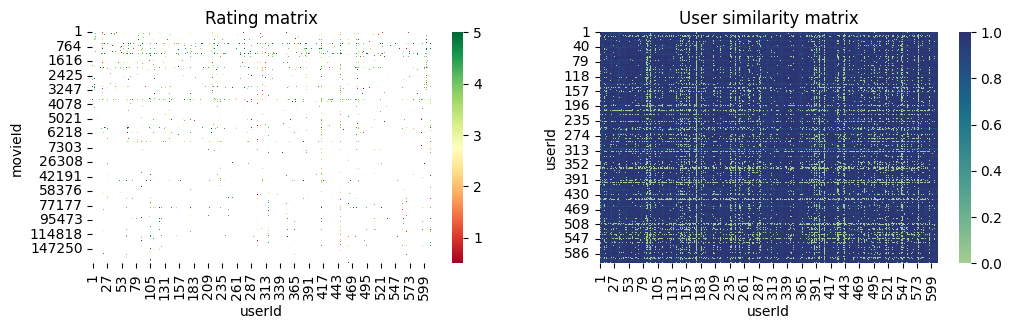

In [22]:
fig, ax = plt.subplots(1, 2, figsize = (12, 3))
sns.heatmap(R_df.transpose(), cmap = "RdYlGn", ax = ax[0])
sns.heatmap(S_df.transpose(), cmap = "crest", ax = ax[1])
ax[0].set_title("Rating matrix")
ax[1].set_title("User similarity matrix");

## 3. Rating prediction

- **Find candidate movies that user $u$ has not watched yet**

In [23]:
userID = 272

rated_movies = movie_rating_df[movie_rating_df.userId == userID].movieId.unique()
candidate_movies = list(set(movie_ids)-set(rated_movies))

print(f"Number of movies watched: {len(rated_movies)}")
print(f"Number of movies not yet watched: {len(candidate_movies)}")

Number of movies watched: 31
Number of movies not yet watched: 9693


- **Predict user $u$'s ratings for unwatched movie $i$**

In [24]:
# Select a movie from the list
movieID = candidate_movies[0]

# Movie i's ratings given by all users
r_i = R_df.loc[:, movieID]

# Similarity between each user and user u
s_u = S_df.loc[userID, :]

# Predict user u's rating for movie i
pred_rating = rating_prediction(r = r_i, s = s_u)

# Print out the predicted rating
movie_title = movie_mapper[movieID]
print(f"Predict user_{userID}'s rating for the movie '{movie_title}': {pred_rating:.1f}")

Predict user_272's rating for the movie 'Toy Story (1995)': 3.9


- **Recommend 10 movies:** Given a user ID. Predict this user's rating for all unwatched movies in the top 300 list. Recommend 10 movies to this user based on predicted ratings.

In [25]:
# The top 300 movies are selected based on the number of ratings from users, whether those ratings are high or low.
top_300_movieIDs = movie_rating_df.movieId.value_counts().head(300).index

In [26]:
userID = 272

# Find candidate movies from the top 300 list that the user has not watched yet
rated_movies = movie_rating_df[movie_rating_df.userId == userID].movieId.unique()
candidate_movies = list(set(top_300_movieIDs)-set(rated_movies))

# Similarity between each user and user u
s_u = S_df.loc[userID, :]

# Predict ratings for each movie in candidate_movies
pred_ratings = [rating_prediction(r = R_df.loc[:, movieID], s = s_u) for movieID in candidate_movies]

# Retrieve the titles for each movieID in candidate_movies
titles = [movie_mapper[movieID] for movieID in candidate_movies]

# Select the top 10 recommendations to display
recommendations = pd.DataFrame({"title": titles, "pred_rating": pred_ratings})
recommendations.nlargest(10, "pred_rating")

,title,pred_rating
239,"Godfather, The (1972)",4.312152
255,Fight Club (1999),4.275330
224,Dr. Strangelove or: How I Learned to Stop Worr...,4.275246
55,"Princess Bride, The (1987)",4.264786
256,Casablanca (1942),4.256082
71,"Godfather: Part II, The (1974)",4.248101
64,Goodfellas (1990),4.246579
140,"Departed, The (2006)",4.245403
166,Schindler's List (1993),4.243491
66,"Dark Knight, The (2008)",4.241630
